# Math 485 Assingnment 3

## Objective
You are to explore the use of Singular Value Decomposition (SVD) for compressing grayscale
images. The goal is to apply block-wise SVD, retaining only the top-𝑘 singular values in each
block, and to analyze how image quality and compression ratio evolve with 𝑘 ∈ {1, 2, ..., 8}.


### Tasks

#### Task1 Preprocessing

Choose any image of your choice (recommended: 256×256 or 512×512 resolution).

Convert it to grayscale (if needed) and crop/resize so both dimensions are divisible by 8.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import  Image


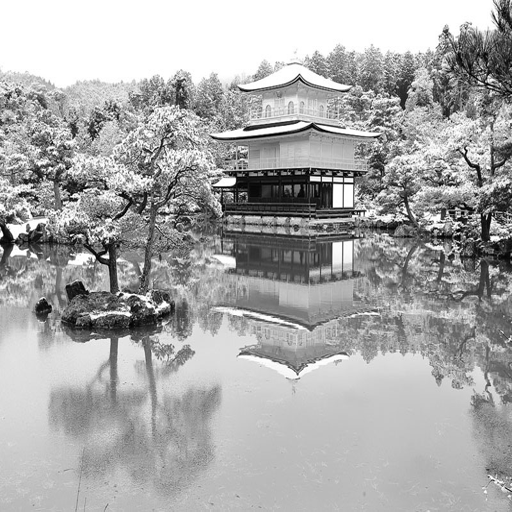

In [2]:
#load image and convert to grayscale
img_path = "image.jpg"
img = Image.open(img_path).convert("L")
img = img.resize((512,512))
img

In [3]:
A = np.array(img, dtype=np.float64)
A.shape

(512, 512)

### Task2 Block-wise SVD Function

Partition the image into non-overlapping 8×8 blocks.

Implement a function compress_block(block, k) that:

- Applies SVD to the block.

- Reconstructs it using only the top-𝑘 singular values.

- Returns the reconstructed block.
    
Carefully handle recombining blocks into a final image.

In [4]:
# apply SVD and reconstruct based on k value
def compress_block(block, k):
    U, S, VT = np.linalg.svd(block, full_matrices=False)

    Ak = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
    return Ak


In [5]:
def compress_reconstruct(img: Image.Image, k: int):
    A = np.array(img, dtype=np.float64)
    h, w = A.shape
    output = np.zeros((h,w))

    for i in range(0,h,8):
        for j in range(0,w,8):
            block = A[i:i+8, j:j+8]
            output[i:i+8, j:j+8] = compress_block(block, k)

    return output

### Task3 Compression Analysis

For each 𝑘 ∈ {1, ..., 8}:

* Apply the block-wise SVD compression.
* Compute the compression ratio:　Compression Ratio = Original Data per block / Data retained per block after top-k
* For an 8×8 block:
    - Original = 64 values
    - With top-𝑘 SVD: k*(8+8+1) values (U: 8×k, Σ: k, Vᵀ: k×8)
* Save the compressed and reconstructed image for each k.


In [6]:
ratios = {}

#creating images with different k values
#and calculate compression ratio
for i in range(8):
    result = compress_reconstruct(img, i+1)
    result = Image.fromarray(result.astype(np.uint8))
    result.save(f"output/reconstruct_l{i+1}.jpg")
    ratios[i+1] = 64 / ((i+1)*(8+8+1))

In [7]:
for k, ratio in ratios.items():
    print(f"k: {k}, compression ratio {ratio:.4f}")

k: 1, compression ratio 3.7647
k: 2, compression ratio 1.8824
k: 3, compression ratio 1.2549
k: 4, compression ratio 0.9412
k: 5, compression ratio 0.7529
k: 6, compression ratio 0.6275
k: 7, compression ratio 0.5378
k: 8, compression ratio 0.4706


### Task4 Visualization

* Plot Compression Ratio vs. k
* Plot Reconstruction Error (Frobenius norm) vs. k
        
    - Optional: For visual quality comparison, try computing PSNR (Peak Signal-to-Noise Ratio).


Text(0, 0.5, 'compression ratio')

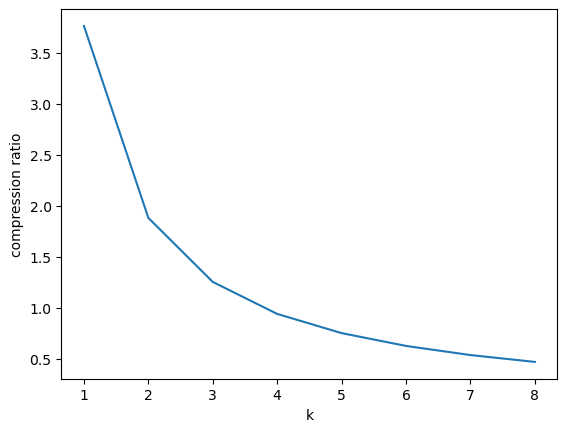

In [8]:
ratios_df = pd.Series(ratios)

#visualization for compression ratio
plt.plot(ratios_df)
plt.xlabel("k")
plt.ylabel("compression ratio")

Text(0, 0.5, 'reconstruction error')

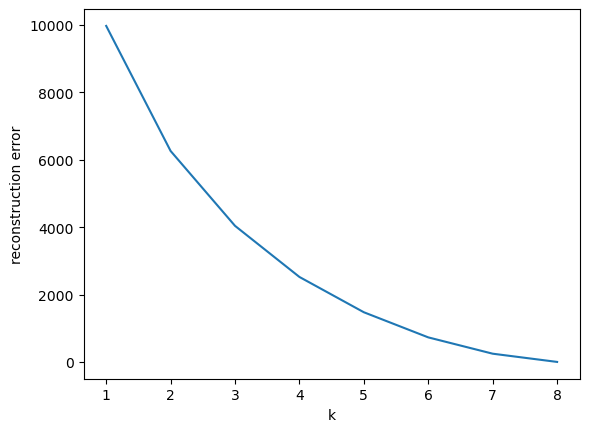

In [9]:
original = A
error = {}

#compute reconstruction error
for i in range(8):
    re_img = compress_reconstruct(img, i+1)
    error[i+1] = np.linalg.norm(original - re_img)

error_df = pd.Series(error)

#visualization for reconstruction ratio
plt.plot(error_df)
plt.xlabel("k")
plt.ylabel("reconstruction error")


### Task5 Experiment with Other Block Sizes

* Try other block sizes such as 4x4, 16x16 etc.
* Analyze how it impacts the compression ratio vs reconstruction error.

In [10]:
#re-creating `compress_reconstruction` so that the block size can be specified
def compress_reconstruct(img: Image.Image, k: int, block_size: int):
    A = np.array(img, dtype=np.float64)
    h, w = A.shape
    output = np.zeros((h,w))

    for i in range(0,h,block_size):
        for j in range(0,w,block_size):
            block = A[i:i+block_size, j:j+block_size]
            output[i:i+block_size, j:j+block_size] = compress_block(block, k)

    return output

In [11]:
#creating new fuction to calculate compression ratio and reconstruction error
def calculate_ratio_error(img, re_img, k, block_size):
    ratio = (block_size*block_size)/((k)*(2*block_size+1))
    error = np.linalg.norm(img - re_img)

    return ratio, error

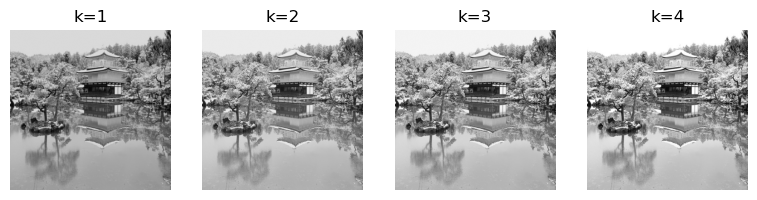

In [12]:
# block_size: 4 * 4
block_size = 4
ratios = {}
errors = {}

plt.figure(figsize=(12,3))
for i in range(block_size):
    result = compress_reconstruct(img, i+1, block_size)
    ratio, error = calculate_ratio_error(img, result, i+1, block_size)
    ratios[i+1] = ratio
    errors[i+1] = error

    plt.subplot(1, block_size+1, i+1)
    plt.imshow(result, cmap="gray")
    plt.axis(False)
    plt.title(f"k={i+1}")


Text(0, 0.5, 'reconstruction errors')

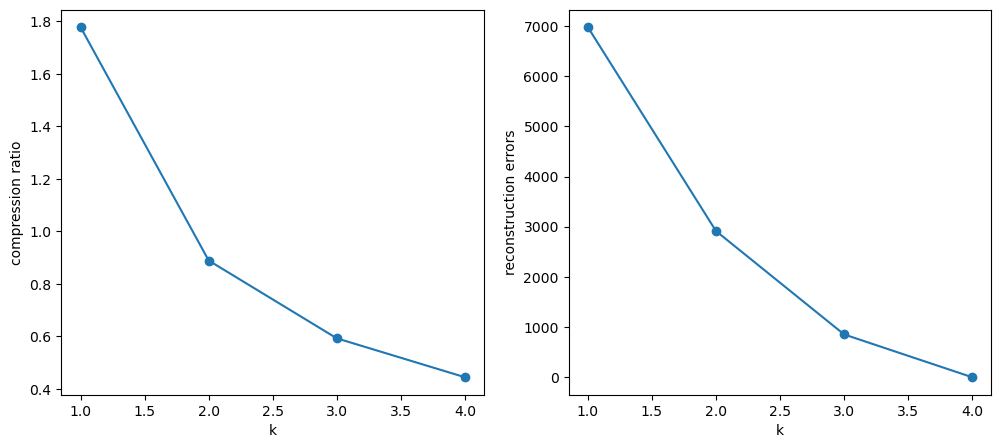

In [13]:
ratios_df = pd.Series(ratios)
errors_df = pd.Series(errors)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(ratios_df,marker="o")
plt.xlabel("k")
plt.ylabel("compression ratio")
plt.subplot(1,2,2)
plt.plot(errors_df, marker="o")
plt.xlabel("k")
plt.ylabel("reconstruction errors")   

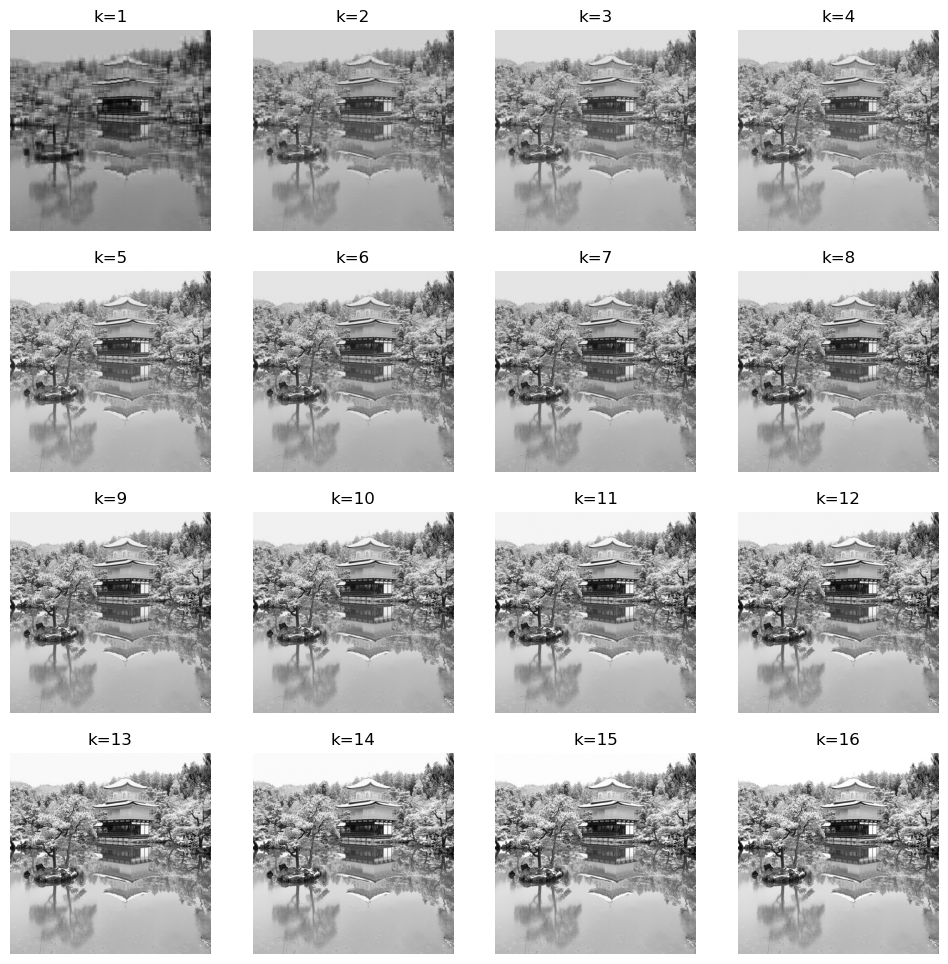

In [14]:
# block_size: 16 * 16
block_size = 16
ratios = {}
errors = {}
plt.figure(figsize=(12,12))
for i in range(block_size):
    result = compress_reconstruct(img, i+1, block_size)
    ratio, error = calculate_ratio_error(img, result, i+1, block_size)
    ratios[i+1] = ratio
    errors[i+1] = error

    plt.subplot(4, 4, i+1)
    plt.imshow(result, cmap="gray")
    plt.axis(False)
    plt.title(f"k={i+1}")
    

Text(0, 0.5, 'reconstruction errors')

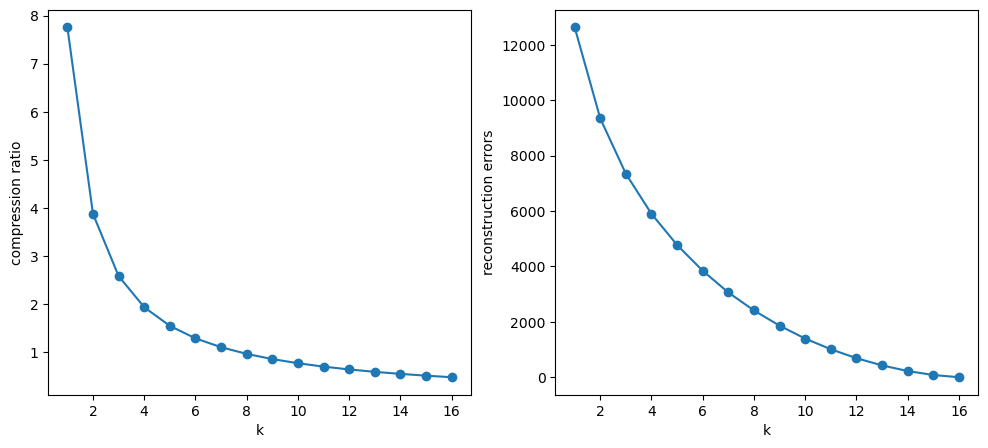

In [15]:
ratios_df = pd.Series(ratios)
errors_df = pd.Series(errors)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(ratios_df,marker="o")
plt.xlabel("k")
plt.ylabel("compression ratio")
plt.subplot(1,2,2)
plt.plot(errors_df, marker="o")
plt.xlabel("k")
plt.ylabel("reconstruction errors")